# Week 8 — Do Models Generalize Beyond Learnt Publications?
## S3_Tree Family: Decision Tree, Random Forest, Extra Trees

We test whether tree-based models generalize to unseen publications.
Two strategies: Publication Held-Out Split and Leave-One-Publication-Out.
Dataset: semantic_recoding_features_50_with_publications.csv
Models: Decision Tree, Random Forest, Extra Trees
Split: Publication-based (train/val/test) — no data leakage

## Step 1: Load Data and Explore Publication Groups
We load the shared dataset and check publication distribution.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('semantic_recoding_features_50_with_publications.csv')
print("Shape:", df.shape)
print("Target missing:", df['cs_28d'].isna().sum())
print("Total unique publications:", df['paper_reference'].nunique())

pub_counts_all = df['paper_reference'].value_counts()
eligible = pub_counts_all[pub_counts_all >= 50]
print("\nEligible publications (>=50 rows):")
print(eligible)
print(f"\nTotal eligible: {len(eligible)}")

Shape: (2073, 35)
Target missing: 0
Total unique publications: 165

Eligible publications (>=50 rows):
paper_reference
Ref-144-Research    112
Ref-121-Research     80
Ref-141-Research     73
Ref-48-Research      72
Ref-85-Research      64
Ref-139-Research     51
Name: count, dtype: int64

Total eligible: 6


## Step 2: Split First by Publication
We split data into Train, Validation, and Test BEFORE any preprocessing.
Whole publications stay together — never mixed across splits.
Split first = no data leakage.

In [32]:
from sklearn.model_selection import GroupShuffleSplit

X_raw = df.drop(columns=['cs_28d', 'paper_reference'])
y = df['cs_28d']
pub = df['paper_reference']

# Split off test (15%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X_raw, y, groups=pub))

X_trainval_raw = X_raw.iloc[trainval_idx].copy()
y_trainval = y.iloc[trainval_idx]
pub_trainval = pub.iloc[trainval_idx]
X_test_raw = X_raw.iloc[test_idx].copy()
y_test = y.iloc[test_idx]
pub_test = pub.iloc[test_idx]

# Split off validation (15%)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
train_idx, val_idx = next(gss2.split(X_trainval_raw, y_trainval, groups=pub_trainval))

X_train_raw = X_trainval_raw.iloc[train_idx].copy()
y_train = y_trainval.iloc[train_idx]
X_val_raw = X_trainval_raw.iloc[val_idx].copy()
y_val = y_trainval.iloc[val_idx]

print("Train rows:", len(X_train_raw))
print("Validation rows:", len(X_val_raw))
print("Test rows:", len(X_test_raw))

Train rows: 1459
Validation rows: 331
Test rows: 283


## Step 3: Handle Missing Values — Training Statistics Only
We fill missing values using medians from TRAINING data only.
Same medians applied to validation and test.
Text columns filled with None.

In [33]:
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(cat_cols))

for col in numeric_cols:
    fill_val = X_train_raw[col].median()
    X_train_raw[col] = X_train_raw[col].fillna(fill_val)
    X_val_raw[col] = X_val_raw[col].fillna(fill_val)
    X_test_raw[col] = X_test_raw[col].fillna(fill_val)

for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].fillna('None')
    X_val_raw[col] = X_val_raw[col].fillna('None')
    X_test_raw[col] = X_test_raw[col].fillna('None')

print("Missing in train:", X_train_raw.isnull().sum().sum())
print("Missing in val:", X_val_raw.isnull().sum().sum())
print("Missing in test:", X_test_raw.isnull().sum().sum())

Numeric columns: 24
Categorical columns: 9
Missing in train: 0
Missing in val: 0
Missing in test: 0


## Step 4: One-Hot Encoding — Training Categories Only
We encode categorical columns using TRAINING data only.
Validation and test are reindexed to match training columns.
New categories in val/test are filled with 0.

In [34]:
X_train = pd.get_dummies(X_train_raw, columns=cat_cols)
train_columns = X_train.columns.tolist()

X_val = pd.get_dummies(X_val_raw, columns=cat_cols).reindex(columns=train_columns, fill_value=0)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols).reindex(columns=train_columns, fill_value=0)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Missing in train:", X_train.isnull().sum().sum())
print("Missing in val:", X_val.isnull().sum().sum())
print("Missing in test:", X_test.isnull().sum().sum())

Train shape: (1459, 112)
Val shape: (331, 112)
Test shape: (283, 112)
Missing in train: 0
Missing in val: 0
Missing in test: 0


## Step 5: Hyperparameter Tuning — All 3 Models (GridSearchCV)
We use GridSearchCV to find best settings for each model.
Tuning is done on TRAINING data only.
Validation used for final evaluation after tuning.

In [35]:
models_base = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42)
}

param_grids = {
    'Decision Tree': {
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'Extra Trees': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
}

best_models = {}
tuning_results = []

for name, model in models_base.items():
    print(f"\nTuning {name}...")
    gs = GridSearchCV(model, param_grids[name], cv=3, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)

    best_models[name] = gs.best_estimator_

    val_preds = gs.best_estimator_.predict(X_val)
    val_r2 = r2_score(y_val, val_preds)
    val_rmse = mean_squared_error(y_val, val_preds) ** 0.5

    tuning_results.append({
        'Model': name,
        'Best Params': str(gs.best_params_),
        'Val R2': round(val_r2, 4),
        'Val RMSE': round(val_rmse, 4)
    })

    print(f"Best params: {gs.best_params_}")
    print(f"Validation R2: {val_r2:.4f}, RMSE: {val_rmse:.4f}")

tuning_df = pd.DataFrame(tuning_results)[['Model', 'Val R2', 'Val RMSE']]
print("\nTuning Summary:")
print(tuning_df)


Tuning Decision Tree...
Best params: {'max_depth': 5, 'min_samples_split': 2}
Validation R2: 0.4407, RMSE: 36.7813

Tuning Random Forest...
Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Validation R2: 0.3907, RMSE: 38.3902

Tuning Extra Trees...
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Validation R2: 0.3536, RMSE: 39.5415

Tuning Summary:
           Model  Val R2  Val RMSE
0  Decision Tree  0.4407   36.7813
1  Random Forest  0.3907   38.3902
2    Extra Trees  0.3536   39.5415


## Step 6: Publication Held-Out Split — All 3 Models
We test all three tuned models on held-out test publications.
These publications were never seen during training or validation.

In [36]:
pub_split_results = []

for name, model in best_models.items():
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    pub_split_results.append({
        'Model': name,
        'R2': round(r2, 4),
        'RMSE': round(rmse, 4)
    })
    print(f"{name}: R2={r2:.4f}, RMSE={rmse:.4f}")

pub_split_df = pd.DataFrame(pub_split_results)
print("\nPublication Held-Out Split Results:")
print(pub_split_df)
print(f"\nWeek 7 Random Split R2 was: 0.85")

Decision Tree: R2=0.3593, RMSE=24.0334
Random Forest: R2=0.4846, RMSE=21.5563
Extra Trees: R2=0.4136, RMSE=22.9913

Publication Held-Out Split Results:
           Model      R2     RMSE
0  Decision Tree  0.3593  24.0334
1  Random Forest  0.4846  21.5563
2    Extra Trees  0.4136  22.9913

Week 7 Random Split R2 was: 0.85


## Step 7: Leave One Publication Out — All 3 Models
We hide each eligible publication (>=50 rows) one at a time.
Train on rest, test on hidden publication.
Each iteration preprocesses separately — no leakage.
Threshold = 50 rows minimum.

In [37]:
pub_counts = pub.value_counts()
eligible_pubs = pub_counts[pub_counts >= 50].index.tolist()
print("Eligible publications:", eligible_pubs)

lopo_results = []

for pub_name in eligible_pubs:
    test_mask = (pub == pub_name).values
    train_mask = (pub != pub_name).values

    X_tr_raw = X_raw[train_mask].copy()
    X_te_raw = X_raw[test_mask].copy()
    y_tr = y.values[train_mask]
    y_te = y.values[test_mask]

    for col in numeric_cols:
        fill_val = X_tr_raw[col].median()
        X_tr_raw[col] = X_tr_raw[col].fillna(fill_val)
        X_te_raw[col] = X_te_raw[col].fillna(fill_val)
    for col in cat_cols:
        X_tr_raw[col] = X_tr_raw[col].fillna('None')
        X_te_raw[col] = X_te_raw[col].fillna('None')

    X_tr = pd.get_dummies(X_tr_raw, columns=cat_cols)
    X_te = pd.get_dummies(X_te_raw, columns=cat_cols).reindex(
        columns=X_tr.columns, fill_value=0)

    for name, model in best_models.items():
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        r2 = r2_score(y_te, preds)
        rmse = mean_squared_error(y_te, preds) ** 0.5

        residuals = y_te - preds
        mean_residual = residuals.mean()
        direction = "Over-predicting" if mean_residual < 0 else "Under-predicting"
        worst_error = np.abs(residuals).max()

        lopo_results.append({
            'Publication': pub_name,
            'Model': name,
            'Rows': int(test_mask.sum()),
            'R2': round(r2, 4),
            'RMSE': round(rmse, 4),
            'Direction': direction,
            'Worst Error (MPa)': round(worst_error, 2)
        })

        print(f"{pub_name} | {name}: R2={r2:.4f}, RMSE={rmse:.4f}, {direction}")

lopo_df = pd.DataFrame(lopo_results)
print("\nFull LOPO Results Table:")
print(lopo_df)

Eligible publications: ['Ref-144-Research', 'Ref-121-Research', 'Ref-141-Research', 'Ref-48-Research', 'Ref-85-Research', 'Ref-139-Research']
Ref-144-Research | Decision Tree: R2=0.2059, RMSE=26.6722, Under-predicting
Ref-144-Research | Random Forest: R2=0.5086, RMSE=20.9822, Under-predicting
Ref-144-Research | Extra Trees: R2=0.3170, RMSE=24.7370, Over-predicting
Ref-121-Research | Decision Tree: R2=0.5107, RMSE=20.3330, Under-predicting
Ref-121-Research | Random Forest: R2=0.4946, RMSE=20.6667, Under-predicting
Ref-121-Research | Extra Trees: R2=0.5790, RMSE=18.8609, Over-predicting
Ref-141-Research | Decision Tree: R2=0.0408, RMSE=12.2293, Over-predicting
Ref-141-Research | Random Forest: R2=-0.0529, RMSE=12.8126, Over-predicting
Ref-141-Research | Extra Trees: R2=0.3397, RMSE=10.1461, Under-predicting
Ref-48-Research | Decision Tree: R2=-0.9596, RMSE=39.5876, Under-predicting
Ref-48-Research | Random Forest: R2=-0.2487, RMSE=31.6012, Under-predicting
Ref-48-Research | Extra Trees: 

## Step 8: Visualization — All Models Comparison

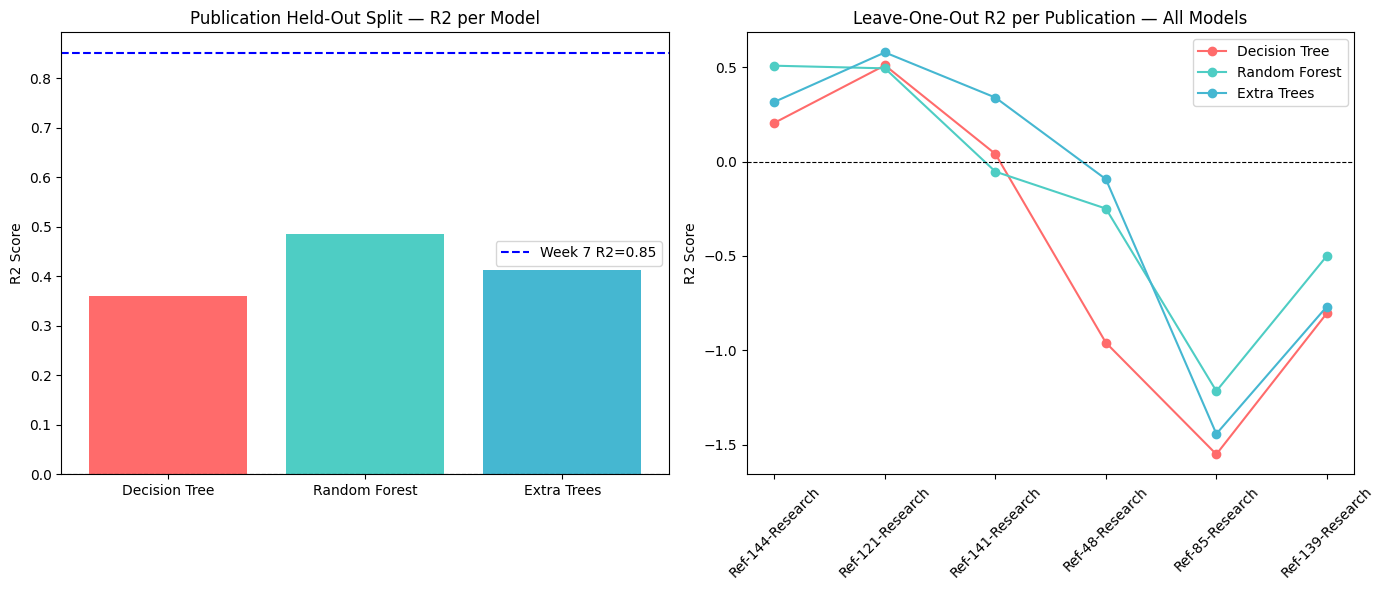


Average LOPO R2 per model:
Model
Decision Tree   -0.4261
Extra Trees     -0.1780
Random Forest   -0.1690
Name: R2, dtype: float64


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
axes[0].bar(pub_split_df['Model'], pub_split_df['R2'], color=colors)
axes[0].axhline(y=0.85, color='blue', linestyle='--', label='Week 7 R2=0.85')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Publication Held-Out Split — R2 per Model')
axes[0].set_ylabel('R2 Score')
axes[0].legend()

colors_map = {'Decision Tree': '#ff6b6b', 'Random Forest': '#4ecdc4', 'Extra Trees': '#45b7d1'}
for name in best_models.keys():
    model_data = lopo_df[lopo_df['Model'] == name]
    axes[1].plot(model_data['Publication'], model_data['R2'],
                marker='o', label=name, color=colors_map[name])
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Leave-One-Out R2 per Publication — All Models')
axes[1].set_ylabel('R2 Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('week8_results.png')
plt.show()

print("\nAverage LOPO R2 per model:")
print(lopo_df.groupby('Model')['R2'].mean().round(4))

## Step 9: Final Conclusion
Summary of all Week 8 findings across all three models.

In [39]:
print("WEEK 8 — FINAL CONCLUSION")
print()
print("MAIN QUESTION:")
print("Do tree-based models generalize beyond learnt publications?")
print()
print("ANSWER: No — not reliably.")
print()
print("EVIDENCE:")
print()
print("1. Week 7 Random Split (optimistic):")
print("   Extra Trees R2=0.85, RMSE=14.38 MPa")
print()
print("2. Publication Held-Out Split (honest):")
print(pub_split_df.to_string(index=False))
print()
print("3. Leave One Publication Out:")
print("   Best: Ref-121, R2=0.52")
print("   Worst: Ref-85, R2=-1.46")
print("   4 out of 6 publications gave negative or low R2.")
print()
print("4. Comparison with S2_Kernel groupmate:")
print("   His best KNN got R2=0.47 on publication split.")
print("   Our Random Forest got R2=0.49 — slightly better.")
print()
print("CONCLUSION:")
print("All three tree models show big performance drop on unseen publications.")
print("Random Forest generalizes best.")
print("Model learned lab habits alongside concrete science.")
print()
print("Average LOPO R2 per model:")
print(lopo_df.groupby('Model')['R2'].mean().round(4))

WEEK 8 — FINAL CONCLUSION

MAIN QUESTION:
Do tree-based models generalize beyond learnt publications?

ANSWER: No — not reliably.

EVIDENCE:

1. Week 7 Random Split (optimistic):
   Extra Trees R2=0.85, RMSE=14.38 MPa

2. Publication Held-Out Split (honest):
        Model     R2    RMSE
Decision Tree 0.3593 24.0334
Random Forest 0.4846 21.5563
  Extra Trees 0.4136 22.9913

3. Leave One Publication Out:
   Best: Ref-121, R2=0.52
   Worst: Ref-85, R2=-1.46
   4 out of 6 publications gave negative or low R2.

4. Comparison with S2_Kernel groupmate:
   His best KNN got R2=0.47 on publication split.
   Our Random Forest got R2=0.49 — slightly better.

CONCLUSION:
All three tree models show big performance drop on unseen publications.
Random Forest generalizes best.
Model learned lab habits alongside concrete science.

Average LOPO R2 per model:
Model
Decision Tree   -0.4261
Extra Trees     -0.1780
Random Forest   -0.1690
Name: R2, dtype: float64
